In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pyinform.utils import coalesce
from pyinform import transfer_entropy
import networkx as nx

In [3]:
# 0. Load data
data = np.genfromtxt("data.csv", delimiter=",", skip_header=1)

# 1. Normalize calcium imaging intensities (z-score per neuron) 
mean = np.mean(data, axis=1, keepdims=True)
std = np.std(data, axis=1, keepdims=True)

norm_data = (data - mean)/std + 1
# positive_data = norm_data + 1 # data must be positive for transfer entropy

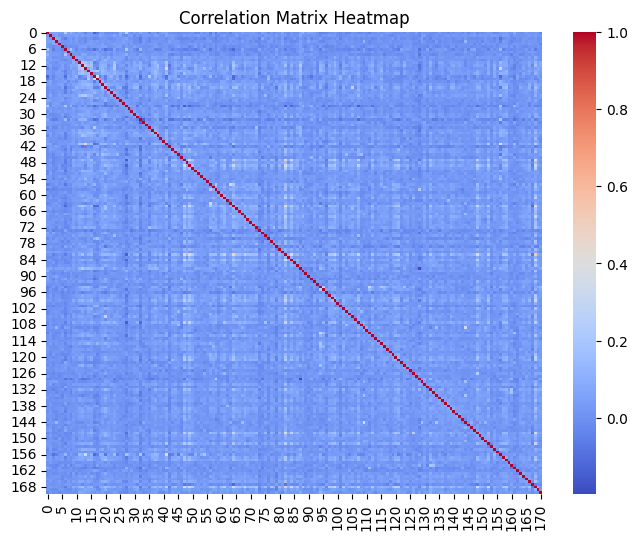

In [18]:
# 2.1. Pearson correlation matrix
corr_matrix = np.corrcoef(norm_data)

# Plot correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, cmap='coolwarm')
plt.title('Correlation Matrix Heatmap')
plt.show()

# Find maximum correlation, excluding 1s (correlation between neuron and itself)
# np.fill_diagonal(corr_matrix, -np.inf)
# print(corr_matrix.max())

In [ ]:
# # 2.2. Transfer entropy matrix
# n_neurons = norm_data.shape[0]

# # Coalesce the series to positive integers for transfer entropy calculation in PyInform
# def coalesce_row(row):
#     # Returns (coalesced_row, base)
#     return coalesce(row)[0]
# coalesced_data = np.apply_along_axis(coalesce_row, 1, norm_data)

# te_matrix = np.zeros((n_neurons, n_neurons))

# k = 1  # history length

# for i in range(n_neurons):
#     for j in range(n_neurons):
#         if i != j:
#             te_matrix[i, j] = transfer_entropy(coalesced_data[i], coalesced_data[j], k=k)

# # Transfer entropy matrix plot
# plt.figure(figsize=(8, 6))
# sns.heatmap(te_matrix, cmap='coolwarm')
# plt.title('Transfer Entropy Matrix Heatmap')
# plt.show()

In [ ]:
# 3. Statistical filtering
# For each pair:
    # Shuffle source neuron
    # Recompute TE
    # Build null distribution
    # Compute p-value
adjacency = (te_matrix > threshold) & (p_values < 0.05)

# 4. Thresholding/sparsification
# Options:
    # Fixed TE threshold
    # Statistical threshold (preferred)
    # Top X% strongest edges
    # False Discovery Rate (FDR)

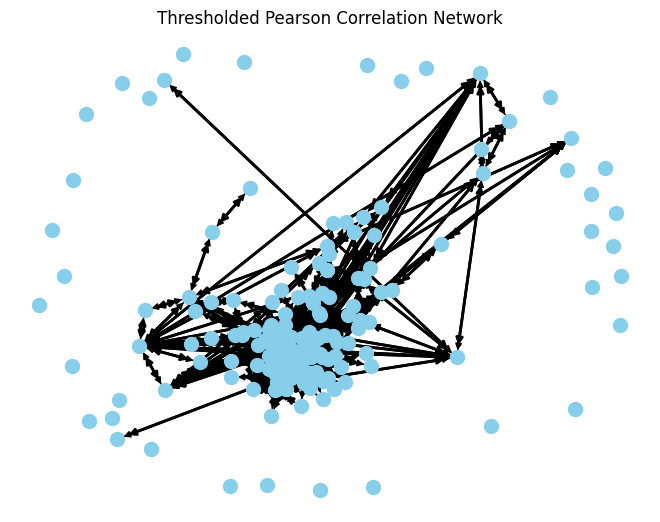

In [21]:
corr_matrix = np.corrcoef(norm_data)

# Remove self-correlations
np.fill_diagonal(corr_matrix, 0)

# Threshold weak correlations
threshold = 0.1
corr_matrix[np.abs(corr_matrix) < threshold] = 0

# Create undirected weighted graph
G = nx.from_numpy_array(corr_matrix, create_using=nx.DiGraph)

pos = nx.spring_layout(G, seed=42)

nx.draw(G, pos,
        node_color='skyblue',
        node_size=100)

nx.draw_networkx_edges(G, pos, width=2, edge_color='black')

# edge_labels = nx.get_edge_attributes(G, 'weight')
# nx.draw_networkx_edge_labels(G, pos) #, edge_labels=edge_labels)

plt.title("Thresholded Pearson Correlation Network")
plt.show()

In [23]:
nx.write_graphml(G, "neurons.graphml") 
# To read back: G = nx.read_graphml("my_graph.graphml")